# <span style="color:black">**Bank Churn** (**CLASSIFICATION**)</span>

<span style="color:black">**L**’objectif de ce projet est de prédire si un client va continuer à utiliser les services de la banque ou s’il va clôturer son compte (churn). Pour ce faire, nous disposons d’un ensemble de données clients contenant plusieurs caractéristiques démographiques, financières et comportementales. Nous devons développer un modèle de prédiction capable de déterminer, pour chaque client, s'il va résilier ou non car cela permet aux banques de mettre en place des stratégies de rétention efficaces.</span>

<span style="color:black">**L**es données :</span>
* <span style="color:black">**Customer ID** : Un identifiant pour chaque client</span>
* <span style="color:black">**Surname** : Le nom de famille du client</span>
* <span style="color:black">**Credit Score** : Une valeur numérique représentant le score de crédit du client</span>
* <span style="color:black">**Geography** : Le pays où réside le client (France, Spain ou Germany)</span>
* <span style="color:black">**Gender** : Le genre du client (Male or Female)</span>
* <span style="color:black">**Age** : L’âge du client</span>
* <span style="color:black">**Tenure** : Le nombre d’années pendant lesquelles le client est avec la banque</span>
* <span style="color:black">**Balance** : Le solde du compte du client</span>
* <span style="color:black">**NumOfProducts** : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit)</span>
* <span style="color:black">**HasCrCard** : Si le client possède une carte de crédit (1 = oui, 0 = non)</span>
* <span style="color:black">**IsActiveMember** : Si le client est un membre actif (1 = oui, 0 = non)</span>
* <span style="color:black">**EstimatedSalary** : Le salaire estimé du client</span>
* <span style="color:black">**Exited** : Si le client a résilié (1 = oui, 0 = non)</span>

<span style="color:black">**L**ien de data : https://www.kaggle.com/competitions/mlpro-classification-bank-churn-2025/data </span>

### <span style="color:black">Sommaire :</span>
* <span style="color:black">Données 3 : Bank Churn
    * <span style="color:black">[Partie 1 : Analyse exploratoire des données (EDA)](#eda)
        * <span style="color:black">[A. Analyse Univariée/ Bivariée](#analyse-univariee-bivariee)
            * <span style="color:black">[Analyse Numérique](#analyse-numerique)
            * <span style="color:black">[Analyse Catégorielle](#analyse-categorielle)
        * <span style="color:black">[B. Analyse Multivariée](#analyse-multivariee)
            * <span style="color:black">[Corrélations Numériques](#correlations-numeriques)
            * <span style="color:black">[Interactions Catégorielles × Catégorielles](#interactions-cat-cat)
            * <span style="color:black">[Interactions Numérique × Catégorielle](#interactions-num-cat)
    * <span style="color:black">[Partie 2 : Formulation et tests d'hypothèses (statistiques)](#tests-hypotheses) : Test t de Student, Test Chi²
    * <span style="color:black">[Partie 3 : Preprocessing](#preprocessing)
        * <span style="color:black">[A. Nettoyage & Sélection des Variables](#nettoyage) 
    * <span style="color:black">[Partie 4 : Modélisation](#modelisation)
        * <span style="color:black">[A. Baseline model](#baseline-model) : Pipeline, Cross-validation
        * <span style="color:black">[B. Gestion du déséquilibre](#gestion-desequilibre) : Feature Engineering
        * <span style="color:black">[C. Random Forest](#random-forest)
    * <span style="color:black">[Partie 5 : Model Optimization](#model-optimization)
        * <span style="color:black">[A. Cross-validation](#cross-validation) (cross_val_score)
        * <span style="color:black">[B. Hyperparameter tuning](#hyperparameter-tuning) (GridSearchCV)
    * <span style="color:black">[Partie 6 : Model Evaluation](#model-evaluation)
        * <span style="color:black">[A. Confusion Matrix](#confusion-matrix)
        * <span style="color:black">[B. Classification Report](#confusion-matrix)
        * <span style="color:black">[C. Feature importance](#feature-importance)
        * <span style="color:black">[D. ROC Curve](#roc-curve)
        * <span style="color:black">[E. Precision–Recall Curve](#precision-recall-curve)
        * <span style="color:black">[F. Threshold Optimization](#threshold-optimization)


    * <span style="color:black">[Kaggle Submission](#kaggle-submission)

In [1]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay

In [2]:
bank_churn = pd.read_csv("train_data.csv")
bank_churn.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


In [3]:
bank_churn.shape

(143579, 14)

In [4]:
bank_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143579 entries, 0 to 143578
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ID               143579 non-null  int64  
 1   CustomerId       143579 non-null  int64  
 2   Surname          143579 non-null  object 
 3   CreditScore      143579 non-null  int64  
 4   Geography        143579 non-null  object 
 5   Gender           143579 non-null  object 
 6   Age              143579 non-null  float64
 7   Tenure           143579 non-null  int64  
 8   Balance          143579 non-null  float64
 9   NumOfProducts    143579 non-null  int64  
 10  HasCrCard        143579 non-null  float64
 11  IsActiveMember   143579 non-null  float64
 12  EstimatedSalary  143579 non-null  float64
 13  Exited           143579 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 15.3+ MB


In [5]:
bank_churn.describe()

,ID,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,143579.000000,1.435790e+05,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000
mean,82521.171097,1.569202e+07,656.411704,38.144476,5.018408,55533.640642,1.553932,0.754107,0.496800,112530.072465,0.212078
std,47650.353367,7.142049e+04,80.210361,8.871711,2.807027,62822.616346,0.546754,0.430617,0.499991,50301.718378,0.408781
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41259.500000,1.563299e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74580.800000,0.000000
50%,82485.000000,1.569018e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117931.100000,0.000000
75%,123793.500000,1.575685e+07,710.000000,42.000000,7.000000,119948.090000,2.000000,1.000000,1.000000,155149.685000,0.000000
max,165033.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


<span style="color:black">**Balance** :</span><br>
* <span style="color:black">**25% = 0**</span><br>
* <span style="color:black">**50% = 0**</span>

<span style="color:black">Donc au moins **50%** des clients ont **balance = 0**.</span>

<span style="color:black">Ça veut dire :</span><br>
* <span style="color:black">*Beaucoup de comptes sans argent* ?</span><br>
* <span style="color:black">Ou *comptes secondaires* ?</span>

In [6]:
bank_churn.isnull().sum()

ID                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
bank_churn["Exited"].value_counts()

Exited
0    113129
1     30450
Name: count, dtype: int64

In [8]:
bank_churn["Exited"].value_counts(normalize=True)

Exited
0    0.787922
1    0.212078
Name: proportion, dtype: float64

* <span style="color:black">78.79% restent</span>
* <span style="color:black">21.21% churn</span>

<a id="eda"></a>

### <span style="color:black">Partie 1 : Analyse exploratoire des données (EDA)</span>

<a id="analyse-univariee-bivariee"></a>

##### <span style="color:black">**A. Analyse Univariée/ Bivariée**</span>

<a id="analyse-numerique"></a>

<span style="color:black">**Analyse Numérique**</span>

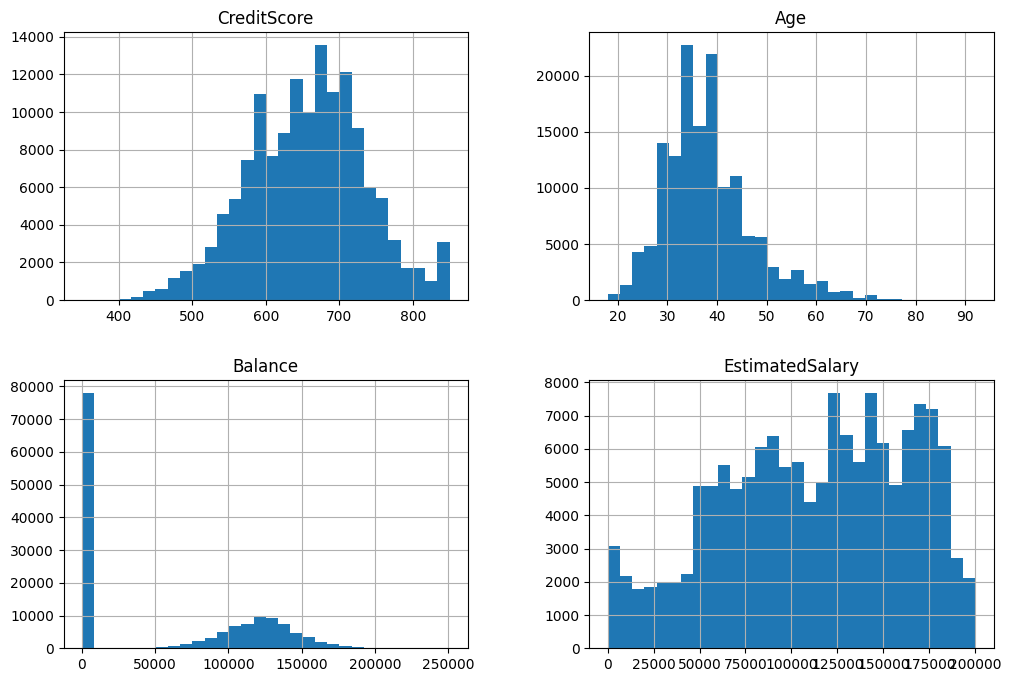

In [9]:
numeric_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

bank_churn[numeric_cols].hist(figsize=(12,8), bins=30)
plt.show()

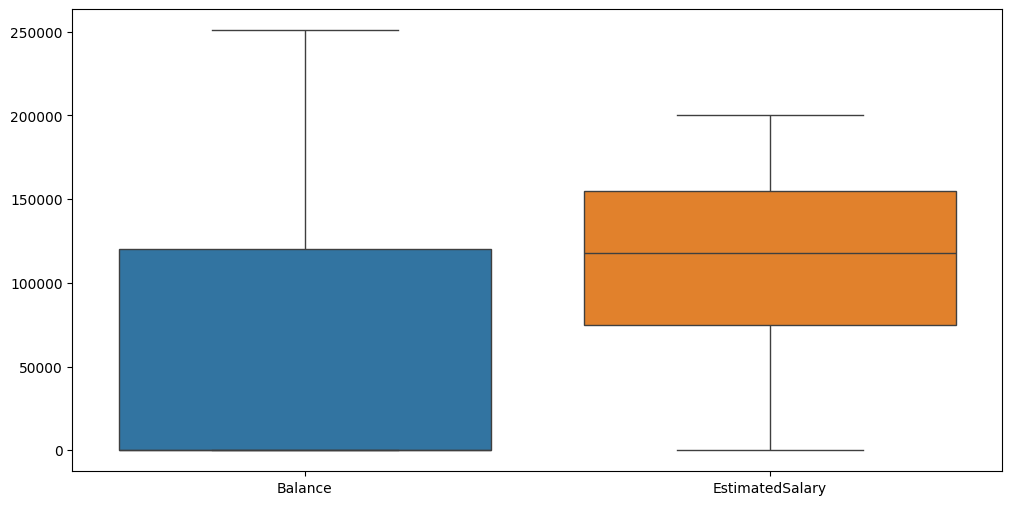

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=bank_churn[["Balance", "EstimatedSalary"]])
plt.show()

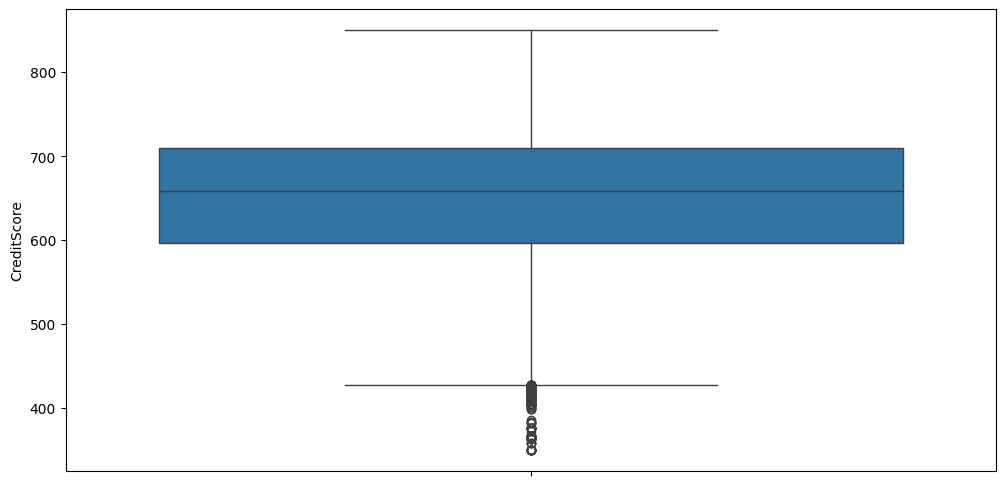

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(data=bank_churn["CreditScore"])
plt.show()

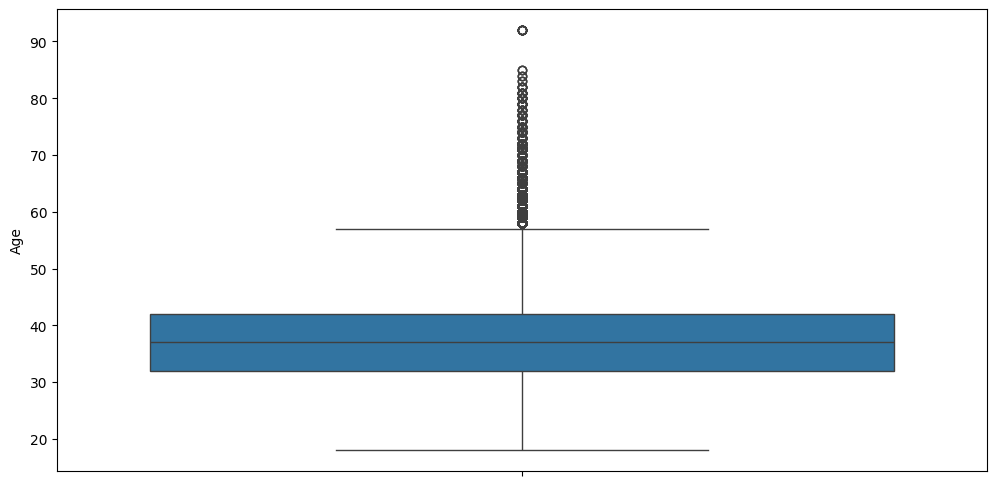

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=bank_churn["Age"])
plt.show()

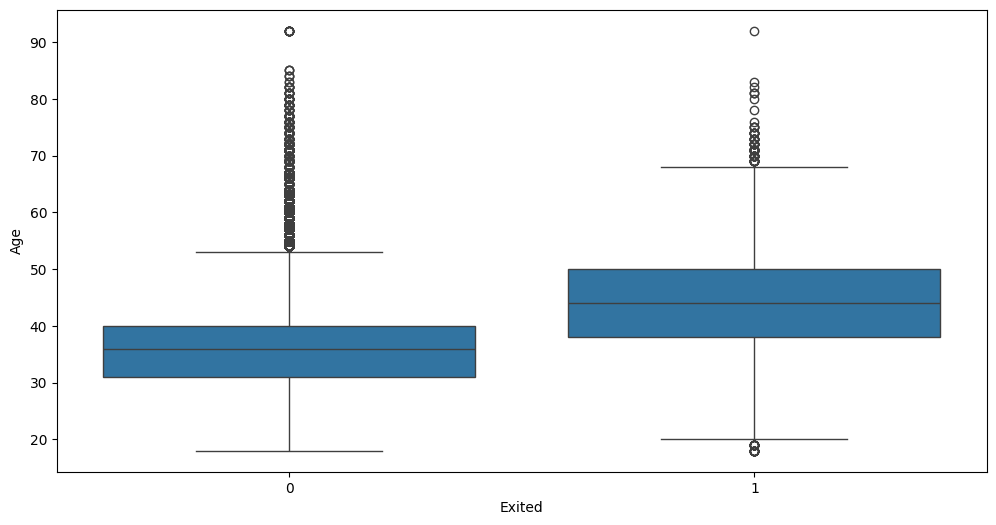

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Exited", y="Age", data=bank_churn)
plt.show()

<span style="color:black">Le boxplot montre que **les clients qui churn ont un âge médian plus élevé que ceux qui restent**. Cela suggère que l’âge pourrait être un facteur explicatif du churn.</span><br><br>
* <span style="color:black">Groupe 0 (reste) :</span>
    * <span style="color:black">Médiane ≈ 35–36 ans</span>
    * <span style="color:black">Distribution concentrée entre 30 et 40</span>
* <span style="color:black">Groupe 1 (churn) :</span>
    * <span style="color:black">Médiane ≈ 44–45 ans</span>
    * <span style="color:black">Distribution plus haute</span>

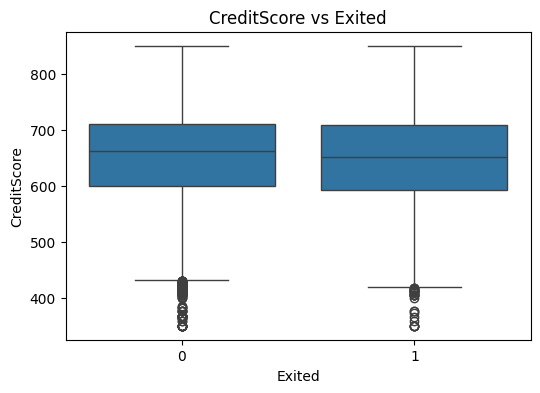

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="CreditScore", data=bank_churn)
plt.title("CreditScore vs Exited")
plt.show()

<span style="color:black">Le boxplot montre que **les distributions du score de crédit sont très similaires entre les clients ayant churn et ceux qui sont restés**. Les médianes sont presque identiques et les intervalles interquartiles se chevauchent largement.</span>

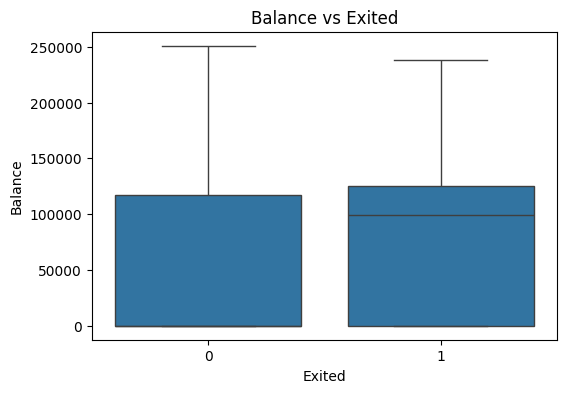

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Balance", data=bank_churn)
plt.title("Balance vs Exited")
plt.show()

<span style="color:black">On observe un décalage plus marqué entre les deux groupes. Les churners présentent une médiane de balance plus élevée que les clients restés. De plus, **une forte proportion de clients ont une balance nulle, ce qui crée une distribution bimodale**.</span>

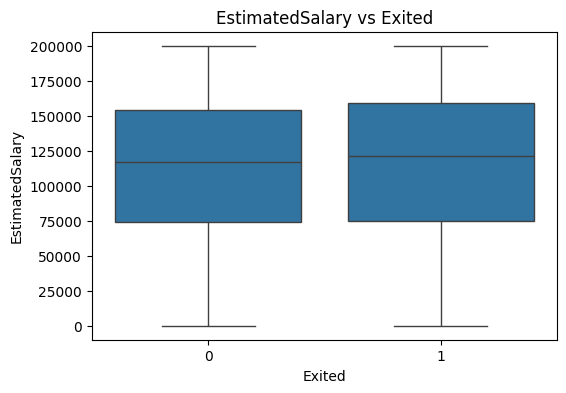

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="EstimatedSalary", data=bank_churn)
plt.title("EstimatedSalary vs Exited")
plt.show()

<span style="color:black">**Les distributions du salaire estimé sont quasiment identiques entre les churners et les non-churners**. Les médianes sont très proches et aucune différence significative visuelle n’apparaît.</span>

In [17]:
pd.crosstab(bank_churn["Tenure"], bank_churn["Exited"], normalize="index")

Exited,0,1
Tenure,,
0,0.744133,0.255867
1,0.772512,0.227488
2,0.805023,0.194977
3,0.771265,0.228735
4,0.772563,0.227437
5,0.779832,0.220168
6,0.802712,0.197288
7,0.811684,0.188316
8,0.800223,0.199777


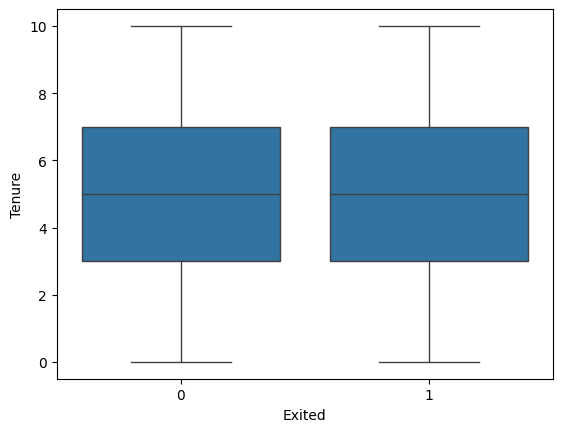

In [18]:
sns.boxplot(x="Exited", y="Tenure", data=bank_churn)
plt.show()

<span style="color:black">On observe :</span>
* <span style="color:black">Un churn légèrement plus élevé chez les très nouveaux clients (0 an).</span>
* <span style="color:black">Ensuite stabilisation autour de 19–22%.</span>
* <span style="color:black">Pas de relation linéaire claire</span><br>

<span style="color:black">**Tenure semble avoir un effet faible à modéré**.</span><br>


<a id="analyse-categorielle"></a>

<span style="color:black">**Analyse Catégorielle**</span>

In [19]:
pd.crosstab(bank_churn["Gender"], bank_churn["Exited"], normalize="index")

Exited,0,1
Gender,,
Female,0.719307,0.280693
Male,0.840983,0.159017


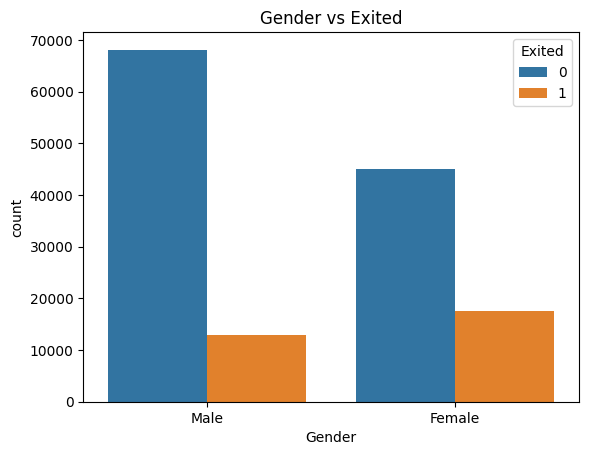

In [20]:
sns.countplot(x="Gender", hue="Exited", data=bank_churn)
plt.title("Gender vs Exited")
plt.show()

<span style="color:black">Les clientes féminins (28.1%) semblent quitter la banque presque deux fois plus que les clients masculins (15.9%).</span><br>
<span style="color:black">**La variable Gender semble fortement associée au churn**.</span>

In [21]:
pd.crosstab(bank_churn["Geography"], bank_churn["Exited"], normalize="index")

Exited,0,1
Geography,,
France,0.834550,0.165450
Germany,0.619731,0.380269
Spain,0.827339,0.172661


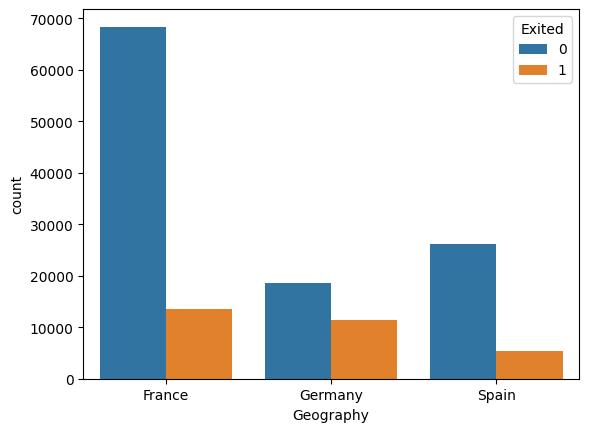

In [22]:
sns.countplot(x="Geography", hue="Exited", data=bank_churn)
plt.show()

<span style="color:black">**Les clients allemands quittent beaucoup plus la banque (38%)** comparés aux clients français (16.5%) et espagnols (17.3%).</span><br>
<span style="color:black">La variable Geography semble extrêmement discriminante.</span>

In [23]:
pd.crosstab(bank_churn["IsActiveMember"], bank_churn["Exited"], normalize="index")

Exited,0,1
IsActiveMember,,
0.0,0.702321,0.297679
1.0,0.874625,0.125375


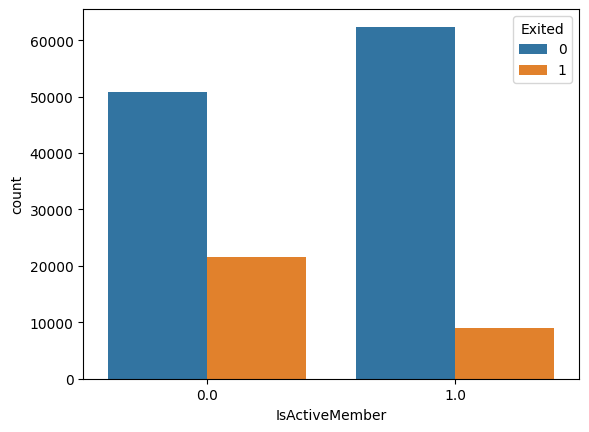

In [24]:
sns.countplot(x="IsActiveMember", hue="Exited", data=bank_churn)
plt.show()

<span style="color:black">Le taux de churn :</span>
* <span style="color:black">29.8% chez les membres inactifs</span>
* <span style="color:black">12.5% chez les membres actifs</span><br>

<span style="color:black">C’est plus du double.</span>


<span style="color:black">La variable IsActiveMember est extrêmement discriminante. C’est logique :</span>
* <span style="color:black">Un client inactif est moins engagé</span>
* <span style="color:black">Moins d’interactions</span>
* <span style="color:black">Moins de produits utilisés</span>
* <span style="color:black">Plus susceptible de partir</span>

In [25]:
pd.crosstab(bank_churn["NumOfProducts"], bank_churn["Exited"], normalize="index")

Exited,0,1
NumOfProducts,,
1,0.651758,0.348242
2,0.939673,0.060327
3,0.116335,0.883665
4,0.131188,0.868812


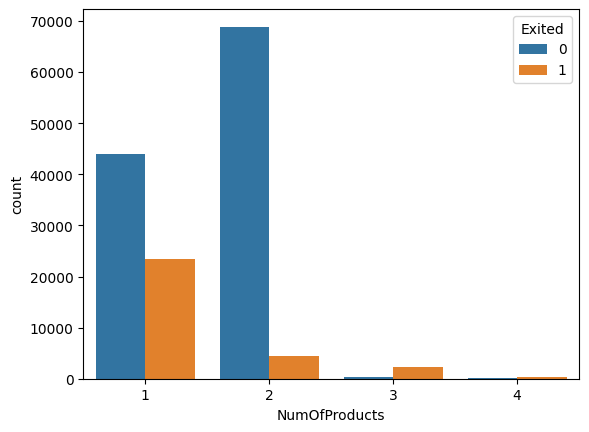

In [26]:
sns.countplot(x="NumOfProducts", hue="Exited", data=bank_churn)
plt.show()

<span style="color:black">La relation n’est pas linéaire. Ce n’est pas “plus de produits = moins de churn”, c'est :</span>
* <span style="color:black">pour 1 produit 35% churn;</span>
* <span style="color:black">pour 2 produits seulement 6% churn;</span>
* <span style="color:black">pour **3 produits 88% churn**;</span>
* <span style="color:black">pour **4 produits 87% churn**.</span>

<span style="color:black">Les clients avec 3–4 produits sont des profils spécifiques (produits risqués ?). Ils ont peut-être souscrit à plusieurs offres promotionnelles.</span>

In [27]:
pd.crosstab(bank_churn["HasCrCard"], bank_churn["Exited"], normalize="index")

Exited,0,1
HasCrCard,,
0.0,0.771732,0.228268
1.0,0.793201,0.206799


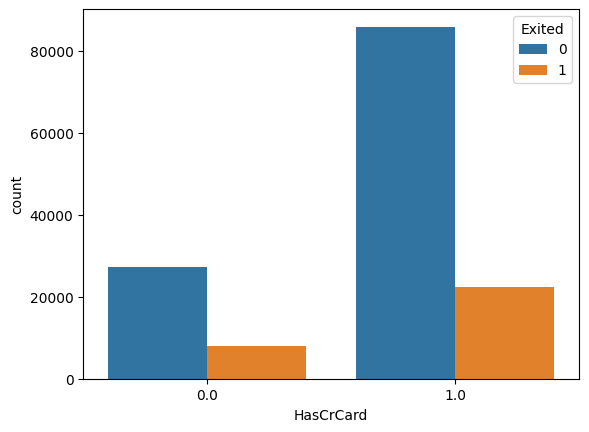

In [28]:
sns.countplot(x="HasCrCard", hue="Exited", data=bank_churn)
plt.show()

<span style="color:black">**Avoir une carte ne semble pas fortement influencer le churn**. C’est un effet très marginal. Peut-être absorbé par NumOfProducts.</span>

<a id="analyse-multivariee"></a>

##### <span style="color:black">**B. Analyse Multivariée**</span>

<a id="correlations-numeriques"></a>

<span style="color:black">**Corrélations Numériques**</span>

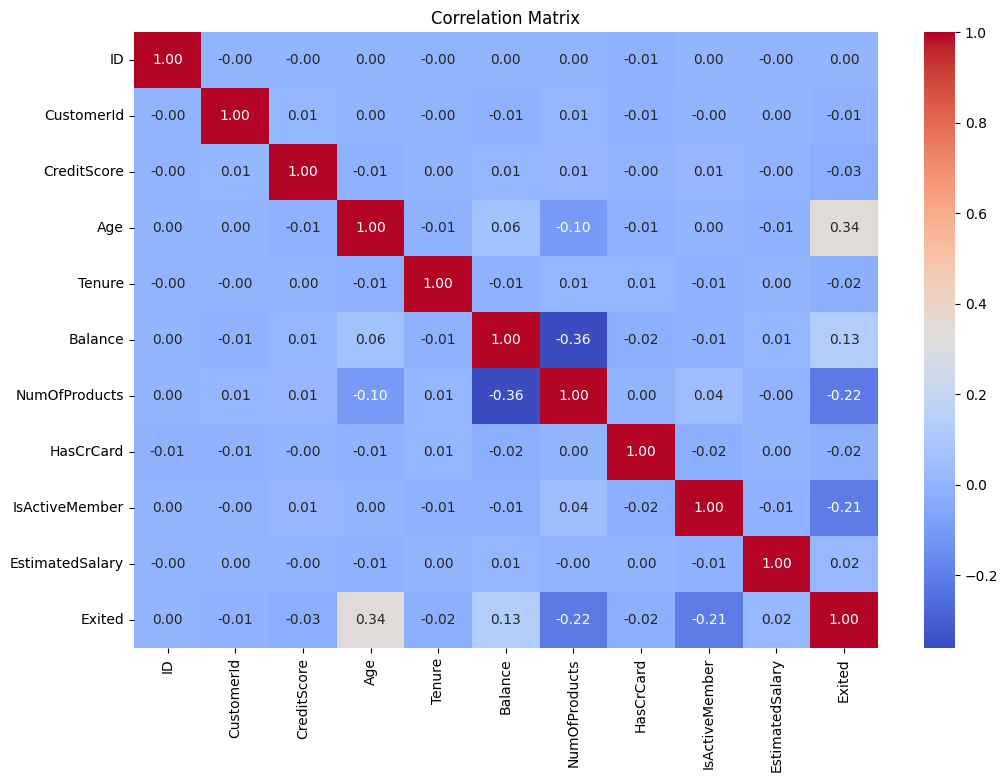

In [29]:
plt.figure(figsize=(12,8))
corr = bank_churn.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

* <span style="color:black">Age = 0.34 : C'est la corrélation la plus forte. → Plus l'âge augmente, plus la probabilité de churn augmente. Ça confirme l’EDA.</span>
* <span style="color:black">NumOfProducts = -0.22 : Corrélation négative. → Plus le nombre de produits augmente, moins on churn. MAIS on a vu que 3–4 produits ont un comportement extrême. Donc, la relation n’est probablement pas linéaire.</span>
* <span style="color:black">IsActiveMember = -0.21 : Actif = moins de churn.</span>
* <span style="color:black">Balance = +0.13 : Faible à modéré. → Balance élevée légèrement associée au churn.</span>

* <span style="color:black">Les autres variables : Très faibles corrélations.</span>

<a id="interactions-cat-cat"></a>

<span style="color:black">**Interactions Catégorielles × Catégorielles**</span>

In [30]:
pd.crosstab(
    [bank_churn["Geography"], bank_churn["IsActiveMember"]],
    bank_churn["Exited"],
    normalize="index"
)

Exited                           0         1
Geography IsActiveMember                    
France    0.0             0.764699  0.235301
          1.0             0.903181  0.096819
Germany   0.0             0.500123  0.499877
          1.0             0.759789  0.240211
Spain     0.0             0.751053  0.248947
          1.0             0.900179  0.099821

<span style="color:black">Le **churn en Allemagne** est particulièrement **élevé chez les clients inactifs**, atteignant près de 50%. Cela suggère que l’engagement client joue un rôle amplificateur dans les marchés à risque.</span>

In [31]:
pd.crosstab(
    [bank_churn["NumOfProducts"], bank_churn["IsActiveMember"]],
    bank_churn["Exited"],
    normalize="index"
)

Exited                               0         1
NumOfProducts IsActiveMember                    
1             0.0             0.539639  0.460361
              1.0             0.780833  0.219167
2             0.0             0.909888  0.090112
              1.0             0.965760  0.034240
3             0.0             0.074226  0.925774
              1.0             0.206508  0.793492
4             0.0             0.079545  0.920455
              1.0             0.228571  0.771429

<span style="color:black">On observe :</span>
* <span style="color:black">2 produits = ultra stable :</span>
    * <span style="color:black">Même inactif → 9%</span>
    * <span style="color:black">Actif → 3%</span>
* <span style="color:black">3 ou 4 produits = catastrophe :</span>
    * <span style="color:black">Même actif → ~77–79%</span>
    * <span style="color:black">Inactif → ~92%</span>
* <span style="color:black">1 produit :</span>
    * <span style="color:black">Inactif → 46%</span>
    * <span style="color:black">Actif → 21%</span><br>


<span style="color:black">L’analyse multivariée révèle que **les clients détenant 3 ou 4 produits présentent un risque extrêmement élevé de churn, particulièrement lorsqu’ils sont inactifs**. Cette interaction suggère qu’un portefeuille multi-produits sans engagement est un signal d’alerte critique.</span>

<a id="interactions-num-cat"></a>

<span style="color:black">**Interactions Numérique × Catégorielle**</span>

In [32]:
bank_churn.groupby(["Gender", "Exited"])["Age"].mean()

Gender  Exited
Female  0         36.713227
        1         44.115220
Male    0         36.498134
        1         43.707650
Name: Age, dtype: float64

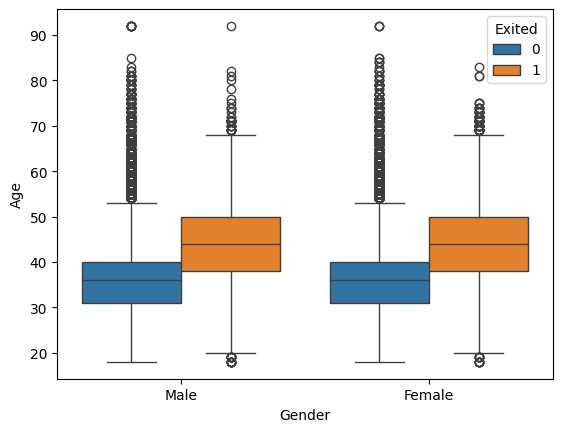

In [33]:
sns.boxplot(x="Gender", y="Age", hue="Exited", data=bank_churn)
plt.show()

<span style="color:black">L’effet de l’âge sur le churn est robuste et présent aussi bien chez les hommes que chez les femmes. **Le genre ne modifie pas significativement la relation entre âge et churn**.</span>

In [34]:
bank_churn.groupby(["Geography", "Exited"])["Age"].mean()

Geography  Exited
France     0         36.427806
           1         43.676926
Germany    0         36.966554
           1         44.299965
Spain      0         36.718311
           1         43.854052
Name: Age, dtype: float64

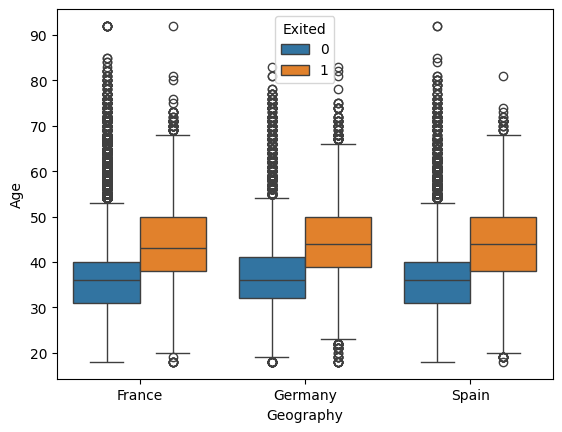

In [35]:
sns.boxplot(x="Geography", y="Age", hue="Exited", data=bank_churn)
plt.show()

<span style="color:black">Bien que le churn soit beaucoup plus élevé en Allemagne, l’effet de l’âge est constant à travers les pays. Cela suggère que **le risque allemand n’est pas lié à une structure d’âge différente**, mais à des facteurs spécifiques au marché.</span>

<a id="tests-hypotheses"></a>

### <span style="color:black">Partie 2 : Formulation et tests d'hypothèses (statistiques)</span>

<span style="color:black">**Test t de Student** :</span>

In [36]:
from scipy import stats

<span style="color:black">(**1**) **<span style="color:blue">Age</span>** vs **<span style="color:orange">Exited</span>** :</span>

<span style="color:black">Le **test t** est approprié ici car nous comparons **la moyenne d’une variable continue entre deux groupes indépendants** définis par une **variable binaire**.</span>

<span style="color:black">Les churners sont-ils significativement plus âgés ?</span><br><br>
<span style="color:black">Hypothèses :</span>
* <span style="color:black">H0 : **μ**churn​ = **μ**non−churn (Il n’y a aucune vraie différence d’âge entre les groupes.)</span>
* <span style="color:black">H1 : **μ**churn​ ≠ **μ**non−churn</span>

In [37]:
age_churn = bank_churn[bank_churn["Exited"] == 1]["Age"]
age_no_churn = bank_churn[bank_churn["Exited"] == 0]["Age"]

t_stat, p_value = stats.ttest_ind(age_churn, age_no_churn)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 136.5764217714973
p-value: 0.0


<span style="color:black">t-stat :</span>
* <span style="color:black">Il est **positif** et **énorme**.</span>
* <span style="color:black">Cela signifie :</span>
    * <span style="color:black">La moyenne des churners est significativement plus élevée.</span>
    * <span style="color:black">L’écart est massif statistiquement.</span><br><br>

<span style="color:black">p-value :</span>
* <span style="color:black">C’est **extrêmement petit** (**proche de 0**).</span>
* <span style="color:black">Donc **p<0.05**.</span>
* <span style="color:black">On rejette H0.</span>
* <span style="color:black">La différence d’âge entre churners et non-churners est **statistiquement significative**.</span><br><br>

<span style="color:black">(**2**) **<span style="color:blue">Tenure</span>** vs **<span style="color:orange">Exited</span>** :</span>

In [38]:
tenure_churn = bank_churn[bank_churn["Exited"] == 1]["Tenure"]
tenure_no_churn = bank_churn[bank_churn["Exited"] == 0]["Tenure"]

t_stat, p_value = stats.ttest_ind(tenure_churn, tenure_no_churn)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -7.327886625063177
p-value: 2.350305291996385e-13


<span style="color:black">p-value :</span>
* <span style="color:black">p-value =2.35×10^(−13)</span><br>
* <span style="color:black">On a : p<0.05</span><br>
* <span style="color:black">Donc on rejette H0.</span><br>
* <span style="color:black">Il existe une différence statistiquement significative entre les moyennes de Tenure.</span><br><br>


<span style="color:black">t-stat :</span>
* <span style="color:black">t-stat = -7.33</span><br>
* <span style="color:black">Le signe négatif signifie : **μ**Tenure,churn=1 < **μ**Tenure,churn=0</span><br>
* <span style="color:black">Et donc les churners ont en moyenne une ancienneté légèrement plus faible.</span><br>

<span style="color:black">Bien que le test t indique une différence significative d’ancienneté entre les groupes (p < 0.001), l’ampleur de l’effet semble modérée comparée à d’autres variables comme l’âge ou l’engagement client.</span>

<span style="color:black">**Test Chi²** :</span>

In [39]:
from scipy.stats import chi2_contingency

<span style="color:black">(**1**) **<span style="color:blue">Gender</span>** vs **<span style="color:orange">Exited</span>** :</span>

<span style="color:black">On teste l’indépendance entre deux variables catégorielles :</span><br><br>
<span style="color:black">Hypothèses :</span>
* <span style="color:black">H0 ​: Gender et Exited sont indépendants</span>
* <span style="color:black">H1 ​: Gender et Exited sont dépendants</span>

In [40]:
contingency_table = pd.crosstab(bank_churn["Gender"], bank_churn["Exited"])
contingency_table

Exited,0,1
Gender,,
Female,45038,17575
Male,68091,12875


In [41]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 3127.515772767467
p-value: 0.0


<span style="color:black">p-value ≈ 0 (extrêmement petite)</span><br>
<span style="color:black">On a : p<0.05</span><br>
<span style="color:black">Donc on rejette H0.</span><br>
<span style="color:black">Et donc Gender et Exited ne sont pas indépendants.</span><br><br>
<span style="color:black">Il existe une association statistiquement significative.</span>

<span style="color:black">Le test du Chi² indique une association significative entre le genre et le churn (p < 0.001). Les clientes présentent un taux de churn nettement supérieur aux clients masculins.</span>

<span style="color:black">(**2**) **<span style="color:blue">Geography</span>** vs **<span style="color:orange">Exited</span>** :</span>

In [42]:
contingency_table = pd.crosstab(bank_churn["Geography"], bank_churn["Exited"])
contingency_table

Exited,0,1
Geography,,
France,68338,13548
Germany,18657,11448
Spain,26134,5454


In [43]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 6455.578335753235
p-value: 0.0


<span style="color:black">p-value :</span>
* <span style="color:black">p-value ≈ 0 (extrêmement petite)</span><br>
* <span style="color:black">On a : p<0.05</span><br>
* <span style="color:black">Donc on rejette H0.</span><br>
* <span style="color:black">Et donc Geography et Exited ne sont pas indépendants.</span><br><br>
* <span style="color:black">Il existe une association statistiquement significative.</span><br><br>

<span style="color:black">Chi² :</span>
* <span style="color:black">Le Chi² est énorme (6455).</span><br>
* <span style="color:black">Ça indique que la structure observée est très éloignée de ce qu’on aurait sous indépendance.</span><br>

<span style="color:black">Le test du Chi² révèle une association très significative entre le pays de résidence et le churn (p < 0.001). L’Allemagne présente un taux de churn nettement supérieur aux autres pays, suggérant un effet spécifique au marché.</span>

<span style="color:black">(**3**) **<span style="color:blue">NumOfProducts</span>** vs **<span style="color:orange">Exited</span>** :</span>

* <span style="color:black">NumOfProducts → variable discrète (4 modalités)</span><br>
* <span style="color:black">Exited → variable catégorielle (0 / 1)</span><br>

<span style="color:black">On teste l’indépendance.</span>

In [44]:
contingency_table = pd.crosstab(bank_churn["NumOfProducts"], bank_churn["Exited"])
contingency_table

Exited,0,1
NumOfProducts,,
1,43905,23459
2,68879,4422
3,292,2218
4,53,351


In [45]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 25393.715822144062
p-value: 0.0


<span style="color:black">p-value :</span>
* <span style="color:black">p-value ≈ 0</span><br>
* <span style="color:black">On a : p<0.05</span><br>
* <span style="color:black">Donc on rejette H0.</span><br>
* <span style="color:black">Et donc NumOfProducts et Exited ne sont PAS indépendants.</span><br><br>
* <span style="color:black">Mais ici ce n’est pas juste significatif.</span><br><br>

<span style="color:black">Chi² :</span>
* <span style="color:black">Le Chi² est gigantesque (25 393).</span><br>
* <span style="color:black">Ça signifie que la distribution observée est extrêmement différente de ce qu’on aurait sous indépendance.</span><br>
* <span style="color:black">Les catégories 3 et 4 sont presque entièrement composées de churners.</span><br>

<span style="color:black">Le nombre de produits présente une association extrêmement forte avec le churn (Chi² très élevé, p < 0.001). Les clients détenant 3 ou 4 produits montrent un taux de résiliation exceptionnellement élevé, ce qui suggère une relation non linéaire et potentiellement structurelle.</span>

<span style="color:black">On pouvait aussi faire avec ANOVA. Puisque NumOfProducts a plus de 2 catégories. On peut tester si la moyenne d’une variable continue diffère selon ces groupes. Mais ici on s’intéresse au churn (binaire), donc le Chi² est plus approprié.</span>

<span style="color:black">(**4**) **<span style="color:blue">IsActiveMember</span>** vs **<span style="color:orange">Exited</span>** :</span>

* <span style="color:black">IsActiveMember → variable catégorielle (0 / 1)</span><br>
* <span style="color:black">Exited → variable catégorielle (0 / 1)</span><br>


<span style="color:black">Deux variables catégorielles, on teste l’indépendance.</span>

<span style="color:black">Hypothèses :</span>
* <span style="color:black">H0 ​: IsActiveMember et Exited sont indépendants</span>
* <span style="color:black">H1 ​: IsActiveMember et Exited sont dépendants</span>

In [46]:
contingency_table = pd.crosstab(bank_churn["IsActiveMember"], bank_churn["Exited"])
contingency_table

Exited,0,1
IsActiveMember,,
0.0,50742,21507
1.0,62387,8943


In [47]:
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 6376.075432276615
p-value: 0.0


<span style="color:black">p-value :</span>
* <span style="color:black">p-value ≈ 0</span><br>
* <span style="color:black">On a : p<0.05</span><br>
* <span style="color:black">Donc on rejette H0.</span><br>
* <span style="color:black">Et donc IsActiveMember et Exited ne sont pas indépendants.</span><br><br>
* <span style="color:black">Il existe une association statistiquement significative.</span>

<span style="color:black">Le test du Chi² indique une association significative entre l’engagement client et le churn (p < 0.001). Les clients inactifs présentent un risque de résiliation nettement supérieur, ce qui confirme l’importance des variables comportementales.</span>

<a id="preprocessing"></a>

### <span style="color:black">Partie 3 : Preprocessing</span>

<a id="nettoyage"></a>

##### <span style="color:black">**A. Nettoyage & Sélection des Variables**</span>

<span style="color:black">**Nettoyage + Split**</span>

In [48]:
bank_churn = bank_churn.drop(columns=["ID", "CustomerId", "Surname"])
bank_churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


In [49]:
X = bank_churn.drop("Exited", axis=1)
y = bank_churn["Exited"]

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # Rend le split reproductible
    stratify=y        # Garde la même proportion de classes
)

In [51]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Exited
0    0.787921
1    0.212079
Name: proportion, dtype: float64
Exited
0    0.787923
1    0.212077
Name: proportion, dtype: float64


<span style="color:black">**Définir les groupes de variables**</span>

In [52]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61
1,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29
2,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54
3,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45
4,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82


In [53]:
numeric_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

categorical_features = [
    "Geography",
    "Gender"
]

binary_features = [
    "HasCrCard",
    "IsActiveMember"
]

<span style="color:black">**Construire le ColumnTransformer**</span>

In [54]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [55]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

<a id="modelisation"></a>

### <span style="color:black">Partie 4 : Modélisation</span>

<a id="baseline-model"></a>

##### <span style="color:black">**A. Baseline model**</span>

<span style="color:black">Objectif : obtenir une première performance.</span>

In [57]:
# 1. Vérifier que le preprocessor marche :
preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)

print("Shape X_train original :", X_train.shape)
print("Shape X_train transformé :", X_train_processed.shape)

Shape X_train original : (114863, 10)
Shape X_train transformé : (114863, 13)


<span style="color:black">**Pipeline** :</span>

In [58]:
# 2. Construire un modèle baseline (Logistic Regression) avec Pipeline :
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [59]:
# 3. Entraîner et faire une première évaluation rapide :
from sklearn.metrics import classification_report, confusion_matrix

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[21606  1020]
 [ 3750  2340]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     22626
           1       0.70      0.38      0.50      6090

    accuracy                           0.83     28716
   macro avg       0.77      0.67      0.70     28716
weighted avg       0.82      0.83      0.81     28716



<span style="color:black">**regarder les probabilités** :</span>

<span style="color:black">(**1**) On **récupère** les **probabilités** :</span>

In [60]:
y_pred = clf.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(28716,))

In [61]:
y_proba = clf.predict_proba(X_test)[:, 1]
y_proba

array([0.31093833, 0.01866403, 0.36643618, ..., 0.38390866, 0.10377628,
       0.05372243], shape=(28716,))

<span style="color:black">Ce sont les probabilités estimées de churn.</span>

<span style="color:black">(**2**) **Calculer** le **ROC-AUC** :</span>

In [62]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)

ROC-AUC: 0.8195380708390612


<span style="color:black">Rappel :</span>
* <span style="color:red">**0.5** = **aléatoire**</span>
* <span style="color:red">**0.7** = **correct**</span>
* <span style="color:red">**0.8+** = **bon**</span>
* <span style="color:red">**0.9+** = **excellent**</span>

<span style="color:black">Donc notre modèle sépare bien les churners des non-churners.</span>

<span style="color:black">(**3**) **Ajuster** le **seuil** :</span>

In [63]:
threshold = 0.3
y_pred_03 = (y_proba >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_03))
print(classification_report(y_test, y_pred_03))

[[19303  3323]
 [ 2266  3824]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     22626
           1       0.54      0.63      0.58      6090

    accuracy                           0.81     28716
   macro avg       0.71      0.74      0.73     28716
weighted avg       0.82      0.81      0.81     28716



<span style="color:black">Comparaison Seuil **0.5** vs **0.3** :</span><br>
<span style="color:black">📌 Avant (seuil **0.5**) :</span>
* <span style="color:black">Recall = 0.38</span>
* <span style="color:black">Precision = 0.70</span>
* <span style="color:black">F1 = 0.50</span>

<span style="color:black">📌 Maintenant (seuil **0.3**) :</span>
* <span style="color:black">Recall = 0.63 ↑</span>
* <span style="color:black">Precision = 0.54 ↓</span>
* <span style="color:black">F1 = 0.58 ↑</span>

<span style="color:black">🔥 Nous avons amélioré :</span>
* <span style="color:black">Recall (38% → 63%)</span>
* <span style="color:black">F1 (0.50 → 0.58)</span>

<span style="color:black">Nous détectons beaucoup plus de churners.</span><br><br>


<span style="color:black">Donc avec seuil 0.3 :</span>
* <span style="color:black">Nous ratons moins de churners</span>
* <span style="color:black">Nous ciblons plus de clients</span>
* <span style="color:black">Mais nous faisons plus de faux positifs</span><br>

<span style="color:black">👉 **Seuil 0.3** est **meilleur** pour churn.</span><br>

<span style="color:black">**Cross-validation** :</span>

In [64]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    clf,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 mean:", scores.mean())
print("F1 std:", scores.std())

F1 mean: 0.4964964839683759
F1 std: 0.001287889284833493


<span style="color:black">Notre baseline Logistic Regression a :</span>
* <span style="color:black">F1 ≈ 0.50</span>
* <span style="color:black">variance très faible (std ≈ 0.001)</span>

<span style="color:black">Donc :</span><br>
<span style="color:black">✔ le modèle est stable</span><br>
<span style="color:black">✔ il généralise correctement</span><br>
<span style="color:black">✔ mais la performance est moyenne</span><br>

<span style="color:black">C’est normal pour un baseline.</span>

<a id="gestion-desequilibre"></a>

##### <span style="color:black">**B. Gestion du déséquilibre**</span>

<span style="color:black">Maintenant qu’on a une baseline stable, on commence l’amélioration du modèle.</span><br>
<span style="color:black">On va commencer par **équilibrer les classes**.</span><br>
<span style="color:black">Notre dataset :</span>
* <span style="color:black">Exited = 1  → 21%</span>
* <span style="color:black">Exited = 0  → 79%</span><br>
<span style="color:black">Le modèle privilégie naturellement la classe majoritaire.</span><br>

<span style="color:black">On teste **class_weight="balanced"**. Cela dit au modèle : *les erreurs sur les churners doivent coûter plus cher*.</span>

<span style="color:black">**Évaluation** du modèle **Logistic Regression** (avec **class_weight="balanced"**) :</span> 

In [65]:
clf_balanced = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [66]:
scores_balanced = cross_val_score(
    clf_balanced,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 mean:", scores_balanced.mean())
print("F1 std:", scores_balanced.std())

F1 mean: 0.558668890209113
F1 std: 0.00350778202028784


<span style="color:black">L’utilisation de **class_weight** *a permis d’améliorer la capacité du modèle à détecter les* clients susceptibles de quitter la banque (*churners*). Le **score F1** est ainsi passé de 0,496 à 0,559 tout *en conservant une faible variance entre les différents plis de la validation croisée*.</span>

In [67]:
clf_balanced.fit(X_train, y_train)

y_pred_bal = clf_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

[[17076  5550]
 [ 1552  4538]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     22626
           1       0.45      0.75      0.56      6090

    accuracy                           0.75     28716
   macro avg       0.68      0.75      0.69     28716
weighted avg       0.82      0.75      0.77     28716



<span style="color:black">Interprétation :</span>
* <span style="color:black">**17076** : vrais non-churn correctement prédits.</span>
* <span style="color:black">**5550** : faux positifs (on pense qu’ils vont partir mais ils restent).</span>
* <span style="color:black">**1552** : faux négatifs (on rate des churners).</span>
* <span style="color:black">**4538** : churners correctement détectés.</span>

<span style="color:black">Notre rapport :</span>
* <span style="color:black">precision = 0.45</span>
* <span style="color:black">recall = 0.75</span>
* <span style="color:black">f1-score = 0.56</span><br>

<span style="color:black">**Recall = 0.75** : Le modèle détecte 75 % des churners. C’est beaucoup mieux qu’avant. Donc on rate beaucoup moins de clients à risque.</span><br>
<span style="color:black">**Precision = 0.45** : Quand le modèle dit qu’un client va churn, il a raison 45 % du temps. Donc la banque ciblerait aussi des clients qui ne vont pas partir. Mais ça peut être acceptable selon la stratégie.</span><br>
<span style="color:black">**F1 = 0.56** : Balanced améliore beaucoup le recall, mais baisse la précision. C’est un trade-off classique.</span><br>
<span style="color:black">**Accuracy = 0.75** : Elle baisse (83 % → 75 %), mais ce n’est pas grave, parce que dans les problèmes déséquilibrés comme le churn, accuracy est trompeuse.</span><br>

<span style="color:black">Conclusion :</span><br>
<span style="color:black">Notre modèle balanced :</span><br>
<span style="color:black">✔ détecte beaucoup plus de churners</span><br>
<span style="color:black">✔ modèle plus utile pour la rétention client</span><br>

<span style="color:black">Mais :</span><br>
<span style="color:black">❗ plus de faux positifs</span><br>
<span style="color:black">Cela signifie que la banque devra contacter plus de clients inutilement.</span>

<span style="color:black">**Feature Engineering**</span>

<span style="color:black">(1) Feature Engineering (nouveaux attributs) :</span>

In [68]:
# Feature 1 : client avec balance = 0
bank_churn["Balance_is_zero"] = (bank_churn["Balance"] == 0).astype(int)

# Feature 2 : clients avec beaucoup de produits
bank_churn["High_products"] = (bank_churn["NumOfProducts"] >= 3).astype(int)

# Feature 3 : groupe d'âge
bank_churn["Age_group"] = pd.cut(
    bank_churn["Age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

In [69]:
bank_churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_is_zero,High_products,Age_group
0,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0,0,0,18-30
1,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0,1,0,30-40
2,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0,1,0,30-40
3,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1,0,1,50-60
4,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0,1,0,30-40


<span style="color:black">(2) Mettre à jour les types de variables :</span>

In [70]:
# Variables catégorielles :
categorical_features = [
    "Geography",
    "Gender",
    "Age_group"
]

# Variables binaires :
binary_features = [
    "HasCrCard",
    "IsActiveMember",
    "Balance_is_zero",
    "High_products"
]

<span style="color:black">(3) Refaire le split :</span>

In [71]:
X = bank_churn.drop("Exited", axis=1)
y = bank_churn["Exited"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<span style="color:black">(4) Recréer le pipeline :</span>

<span style="color:black">Le preprocessor reste le même principe, mais avec les nouvelles listes de colonnes.

In [72]:
clf_balanced = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

<span style="color:black">(5) Cross-validation avec les nouvelles features :</span>

In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    clf_balanced,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 mean:", scores.mean())
print("F1 std:", scores.std())

F1 mean: 0.558668890209113
F1 std: 0.00350778202028784


<span style="color:black">F1 ≈ 0.56 :</span>
* <span style="color:black">variance très faible → modèle stable.</span>
* <span style="color:black">donc la performance est fiable</span>

<span style="color:black">(6) Évaluer sur le test set :</span>

In [74]:
clf_balanced.fit(X_train, y_train)

y_pred = clf_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[17076  5550]
 [ 1552  4538]]
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     22626
           1       0.45      0.75      0.56      6090

    accuracy                           0.75     28716
   macro avg       0.68      0.75      0.69     28716
weighted avg       0.82      0.75      0.77     28716



<span style="color:black">Notre modèle :</span><br>
<span style="color:black">✔ détecte 75% des churners</span><br>
<span style="color:black">✔ F1 = 0.56</span>

<span style="color:black">Mais :</span><br>
<span style="color:black">❗ beaucoup de faux positifs (clients ciblés inutilement)</span><br>
<span style="color:black">Cela peut être acceptable selon la stratégie de la banque.</span>

<a id="random-forest"></a>

##### <span style="color:black">**C. Random Forest**</span>

<span style="color:black">Tester un autre modèle de classification : **Random Forest** : modèle plus puissant pour capturer relations non linéaires./span>

<span style="color:black">(1) Créer le pipeline **Random Forest** :</span>

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

<a id="model-optimization"></a>

### <span style="color:black">Partie 5 : Model Optimization</span>

<a id="cross-validation"></a>

##### <span style="color:black">**A. Cross-validation** (**cross_val_score**)</span>

<span style="color:black">(2) Cross-validation :</span>

In [76]:
from sklearn.model_selection import cross_val_score

scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("RF F1 mean:", scores_rf.mean())
print("RF F1 std:", scores_rf.std())

RF F1 mean: 0.6145287075627872
RF F1 std: 0.005963009937224727


| <span style="color:black">Modèle</span>              | <span style="color:black">F1 CV</span>      |
| ------------------- | ---------- |
| <span style="color:black">Logistic (balanced)</span> | <span style="color:black">**0.5587**</span> |
| <span style="color:black">Random Forest</span>       | <span style="color:black">**0.6145**</span> |



<span style="color:black">👉 RandomForest est clairement meilleur.</span> <br>
<span style="color:black">Et la variance est faible → modèle stable.</span> 

<span style="color:black">(3) Évaluation sur le test set :</span>

In [77]:
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[21379  1247]
 [ 2750  3340]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     22626
           1       0.73      0.55      0.63      6090

    accuracy                           0.86     28716
   macro avg       0.81      0.75      0.77     28716
weighted avg       0.85      0.86      0.85     28716



| <span style="color:black">Metric</span>    | <span style="color:black">Logistic Balanced</span> | <span style="color:black">Random Forest</span> |
| --------- | ----------------- | ------------- |
| <span style="color:black">Precision</span> | <span style="color:black">0.45</span>              | <span style="color:black">**0.73**</span>      |
| <span style="color:black">Recall    | <span style="color:black">**0.75**</span>          | <span style="color:black">0.55</span>          |
| <span style="color:black">F1</span>        | <span style="color:black">0.56</span>              | <span style="color:black">**0.63**</span>      |


<span style="color:black">**Precision** :</span><br>
<span style="color:black">Quand le modèle dit qu’un client va churn, il a raison 73 % du temps.</span>

<span style="color:black">**Recall** :</span><br>
<span style="color:black">Il détecte 55 % des churners.</span><br>
<span style="color:black">Moins que Logistic balanced (0.75), mais encore correct.</span>

<span style="color:black">**F1-score** :</span><br>
<span style="color:black">👉 meilleur compromis précision / recall.</span><br>
<span style="color:black">Donc globalement RandomForest est meilleur.</span>

<span style="color:black">Random Forest outperformed Logistic Regression, achieving an F1-score of 0.63 compared to 0.56 for the logistic model.</span>

<a id="hyperparameter-tuning"></a>

##### <span style="color:black">**B. Hyperparameter tuning** (**GridSearchCV**)</span>

<span style="color:black">(1) Optimisation : GridSearchCV : chercher les meilleurs hyperparamètres</span><br>
<span style="color:black">🎯 But : tester plusieurs RandomForest, choisir la meilleure combinaison de paramètres sur le train via CV.</span>

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV score: 0.6224558900678254


<span style="color:black">Nous avons obtenu (GridSearch) :
* <span style="color:black">Best parameters:
* <span style="color:black">max_depth = None
* <span style="color:black">min_samples_split = 5
* <span style="color:black">n_estimators = 200
* <span style="color:black">Best CV score = 0.622


<span style="color:black">Ce que signifient les meilleurs paramètres :
* <span style="color:black">n_estimators = 200 :
<span style="color:black">Le modèle utilise 200 arbres.
<span style="color:black">Plus d’arbres → modèle plus stable.

* <span style="color:black">max_depth = None :
<span style="color:black">Les arbres peuvent pousser jusqu’à la profondeur maximale.
<span style="color:black">Cela permet de capturer des relations complexes.

* <span style="color:black">min_samples_split = 5 :
<span style="color:black">Un noeud doit avoir au moins 5 observations pour être séparé.
<span style="color:black">Cela aide à réduire le surapprentissage.



<span style="color:black">Comparaison :</span>
| <span style="color:black">Modèle</span>                 | <span style="color:black">F1 CV</span>     |
| ---------------------- | --------- |
| <span style="color:black">Logistic balanced</span>      | <span style="color:black">0.559</span>     |
| <span style="color:black">RandomForest (default)</span> | <span style="color:black">0.615</span>     |
| <span style="color:black">RandomForest (tuned)</span>   | <span style="color:black">**0.622**</span> |

<span style="color:black">👉 L’optimisation améliore légèrement le modèle.</span>

<span style="color:black">(2) Modèle final (best_estimator + fit) :</span>

* <span style="color:black">**best_estimator_** : récupérer le meilleur modèle trouvé :</span>
<span style="color:black">🎯 But : récupérer le pipeline complet (preprocess + modèle) avec les meilleurs paramètres.</span>

* <span style="color:black">Fit final :</span>
<span style="color:black">🎯 But : entraîner le modèle final sur tout le train.</span>

In [79]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

<a id="model-evaluation"></a>

### <span style="color:black">Partie 6 : Model Evaluation</span>

<a id="confusion-matrix"></a>

##### <span style="color:black">**A. Confusion Matrix**<br> **B. Classification Report**</span>

<span style="color:black">(3) Évaluation finale (test set) :</span><br>
<span style="color:black">🎯 But : mesurer la performance réelle sur le test (jamais vu).</span>

In [80]:
y_pred_best = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[21364  1262]
 [ 2734  3356]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     22626
           1       0.73      0.55      0.63      6090

    accuracy                           0.86     28716
   macro avg       0.81      0.75      0.77     28716
weighted avg       0.85      0.86      0.85     28716



<span style="color:black">(1) Résultat du modèle final :
<span style="color:black">Interprétation :
* <span style="color:black">21364 clients correctement identifiés comme non-churn
* <span style="color:black">3356 churners correctement détectés
* <span style="color:black">2734 churners manqués
* <span style="color:black">1262 faux positifs


<span style="color:black">(2) Métriques principales :
<span style="color:black">Classe churn (1) :
| <span style="color:black">Metric    | <span style="color:black">Valeur   |
| --------- | -------- |
| <span style="color:black">Precision | <span style="color:black">**0.73** |
| <span style="color:black">Recall    | <span style="color:black">**0.55** |
| <span style="color:black">F1-score  | <span style="color:black">**0.63** |


<span style="color:black">(3) Comparaison des modèles :
| <span style="color:black">Modèle              | <span style="color:black">Precision | <span style="color:black">Recall   | <span style="color:black">F1       |
| ------------------- | --------- | -------- | -------- |
| <span style="color:black">Logistic Regression | <span style="color:black">0.45      | <span style="color:black">**0.75** | <span style="color:black">0.56     |
| <span style="color:black">Random Forest       | <span style="color:black">**0.73**  | <span style="color:black">0.55     | <span style="color:black">**0.63** |

<span style="color:black">Logistic Regression :
* <span style="color:black">détecte beaucoup de churners
* <span style="color:black">mais beaucoup de faux positifs

<span style="color:black">Random Forest :
* <span style="color:black">prédictions plus fiables
* <span style="color:black">meilleur compromis precision / recall

<span style="color:black">Donc 👉 **Random Forest est le meilleur modèle pour ce projet**.

<span style="color:black">Notre modèle signifie :
* <span style="color:black">quand il détecte un churner → 73% de chances qu'il ait raison
* <span style="color:black">il détecte 55% des churners

<span style="color:black">Donc la banque peut :
* <span style="color:black">cibler les clients à risque
* <span style="color:black">réduire les campagnes inutiles

<a id="feature-importance"></a>

##### <span style="color:black">**C. Feature importance**</span>

<span style="color:black">(4) Interprétabilité (feature importance) :</span><br>
<span style="color:black">🎯 But : expliquer le modèle → quelles variables comptent le plus.</span>

In [81]:
feature_names = best_rf.named_steps["preprocess"].get_feature_names_out()

importances = best_rf.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
1,num__Age,0.250338
4,num__NumOfProducts,0.162573
5,num__EstimatedSalary,0.146495
0,num__CreditScore,0.137225
3,num__Balance,0.110260
2,num__Tenure,0.066249
12,bin__IsActiveMember,0.054586
7,cat__Geography_Germany,0.026150
10,cat__Gender_Male,0.011211
9,cat__Gender_Female,0.010501


<a id="roc-curve"></a>

##### <span style="color:black">**D. ROC Curve**</span>

<span style="color:black">(5) Courbe globale (ROC Curve) :</span><br>
<span style="color:black">🎯 But : évaluer la capacité de discrimination globale (AUC ≈ 0.88 dans votre graphe).</span>

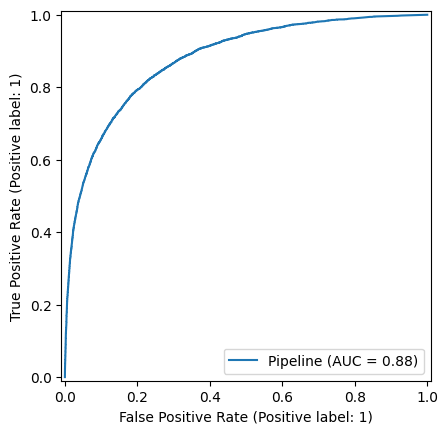

In [82]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_rf, X_test, y_test)

<a id="precision-recall-curve"></a>

##### <span style="color:black">**E. Precision–Recall Curve**</span>

<span style="color:black">La **ROC** peut paraître “bonne” même si la classe 1 est minoritaire.</span>

<span style="color:black">La **courbe Precision–Recall** se concentre sur la performance sur la classe positive (Exited=1).</span>

Average Precision (AP): 0.708891030158538


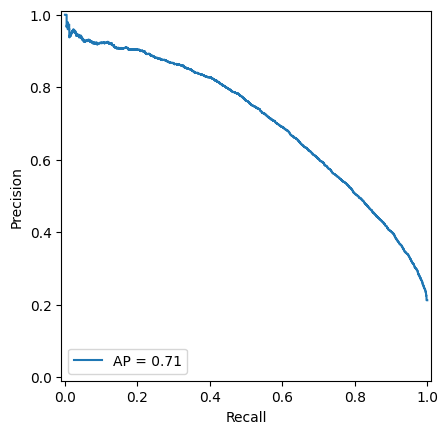

In [83]:
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

# Probabilités de la classe 1 (churn) :
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Calcul de la courbe :
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Score synthétique :
ap = average_precision_score(y_test, y_proba)
print("Average Precision (AP):", ap)

# Affichage :
PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap).plot()
plt.show()

<span style="color:black">AP (Average Precision) résume la courbe Precision–Recall.
* <span style="color:black">AP proche de 1 → excellent
* <span style="color:black">AP proche de la proportion de la classe positive → modèle faible

<span style="color:black">Ici, notre churn est ~21% (0.21).
<span style="color:black">Notre AP = 0.71 est bien au-dessus de 0.21.

<span style="color:black">👉 Donc notre modèle est très bon pour classer les churners en haut du ranking (ce qui est exactement l’objectif en churn).

<span style="color:black">Notre courbe (interprétation simple) :
* <span style="color:black">À gauche (recall faible) : precision très élevée (~0.9+)
<span style="color:black">→ si nous ne ciblons que les “plus risqués”, nous sommes très souvent correcte.

* <span style="color:black">Quand nous augmentons le recall : la precision descend progressivement
<span style="color:black">→ normal : nous attrapons plus de churners, mais nous attrapons aussi plus de non-churners.

<span style="color:black">C’est le trade-off classique.

<span style="color:black">**La courbe Precision–Recall** met en évidence de bonnes performances du modèle, avec une **Average Precision** (**AP**) de 0,71. Cela signifie que **le modèle parvient à bien identifier les clients susceptibles de quitter la banque**, malgré le déséquilibre des classes.</span>

<a id="threshold-optimization"></a>

##### <span style="color:black">**F. Threshold Optimization**</span>

<span style="color:black">Ajuster le seuil pour améliorer le F1 score.</span>

In [84]:
from sklearn.metrics import f1_score

y_proba = best_rf.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold for F1:", best_t)
print("Best F1:", max(f1_scores))

# Rapport au seuil optimal
y_pred_opt = (y_proba >= best_t).astype(int)
print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

Best threshold for F1: 0.35
Best F1: 0.6485718794382199
[[20152  2474]
 [ 1980  4110]]
              precision    recall  f1-score   support

           0       0.91      0.89      0.90     22626
           1       0.62      0.67      0.65      6090

    accuracy                           0.84     28716
   macro avg       0.77      0.78      0.77     28716
weighted avg       0.85      0.84      0.85     28716



<span style="color:black">**Optimisation du seuil de décision** :

<span style="color:black">Avant (RandomForest avec seuil par défaut 0.5) :
| <span style="color:black">Metric    | <span style="color:black">Valeur |
| --------- | ------ |
| <span style="color:black">Precision | <span style="color:black">0.73   |
| <span style="color:black">Recall    | <span style="color:black">0.55   |
| <span style="color:black">F1        | <span style="color:black">0.63   |

<span style="color:black">Maintenant :
| <span style="color:black">Metric    | <span style="color:black">Valeur   |
| --------- | -------- |
| <span style="color:black">Precision | <span style="color:black">**0.62** |
| <span style="color:black">Recall    | <span style="color:black">**0.67** |
| <span style="color:black">F1        | <span style="color:black">**0.65** |

<span style="color:black">Avec ce seuil :
* <span style="color:black">67% des churners sont détectés
* <span style="color:black">62% des clients ciblés sont réellement à risque

<span style="color:black">Donc la banque pourrait :
* <span style="color:black">cibler les clients avec probabilité ≥ 0.35
* <span style="color:black">lancer une campagne de rétention.

<span style="color:black">**Comparaison finale des modèles** :
| <span style="color:black">Modèle                           | <span style="color:black">Precision | <span style="color:black">Recall   | <span style="color:black">F1       |
| -------------------------------- | --------- | -------- | -------- |
| <span style="color:black">Logistic Regression              | <span style="color:black">0.45      | <span style="color:black">**0.75** | <span style="color:black">0.56     |
| <span style="color:black">Random Forest                    | <span style="color:black">**0.73**  | <span style="color:black">0.55     | <span style="color:black">0.63     |
| <span style="color:black">Random Forest + threshold tuning | <span style="color:black">0.62      | <span style="color:black">**0.67** | <span style="color:black">**0.65** |

<span style="color:black">👉 Le meilleur modèle est RandomForest avec seuil optimisé.

<span style="color:black">**Résultat final du projet** :</span><br>
<span style="color:black">Notre modèle final :</span><br>
<span style="color:black">RandomForestClassifier</span><br>
<span style="color:black">+ Hyperparameter tuning</span><br>
<span style="color:black">+ Threshold optimization</span>

<span style="color:black">Performance :</span><br>
<span style="color:black">Precision = 0.62</span><br>
<span style="color:black">Recall = 0.67</span><br>
<span style="color:black">F1 = 0.65</span><br>
<span style="color:black">ROC-AUC ≈ 0.88</span><br>
<span style="color:black">Average Precision ≈ 0.71</span>

*************************************************

*************************************************

<a id="kaggle-submission"></a>

<span style="color:black">**Kaggle Submission** :</span>

In [85]:
test_data = pd.read_csv("test_data.csv")
test_data.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,67897,15585246,Bancks,585,France,Female,53.0,2,0.00,2,1.0,1.0,91830.75
1,163075,15604551,Robb,606,France,Male,24.0,2,0.00,1,0.0,1.0,90876.95
2,134760,15729040,Ugochukwu,633,Germany,Male,44.0,1,118907.60,1,1.0,0.0,47777.15
3,68707,15792329,Hs?,602,Germany,Male,40.0,2,149961.99,2,1.0,1.0,82696.84
4,3428,15617166,Genovesi,645,France,Male,31.0,4,132351.29,1,1.0,0.0,151887.16


In [86]:
test_data["Balance_is_zero"] = (test_data["Balance"] == 0).astype(int)
test_data["High_products"] = (test_data["NumOfProducts"] >= 3).astype(int)

test_data["Age_group"] = pd.cut(
    test_data["Age"],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

In [87]:
X_new = test_data.drop(["ID", "CustomerId", "Surname"], axis=1)

In [88]:
predictions = best_rf.predict(X_new)

submission = pd.DataFrame({
    "ID": test_data["ID"],
    "Exited": predictions
})

submission.to_csv("submission.csv", index=False)
submission.head()

,ID,Exited
0,67897,0
1,163075,0
2,134760,1
3,68707,0
4,3428,0


In [89]:
submission.head()
submission.shape

(21455, 2)

In [90]:
test_data.shape

(21455, 16)

*************************************************

*************************************************